In [34]:
import os
os.environ.pop("MPLBACKEND", None)

import matplotlib.pyplot as plt
%matplotlib inline
import time
from jax import numpy as jnp
import numpy as np
import scipy.io
from sklearn.decomposition import PCA

In [ ]:
data_path = 'data/ps8_data.mat'
data = scipy.io.loadmat(data_path)

Xplan = data['Xplan']
Xsim  = data['Xsim']

print(f"Xplan shape: {Xplan.shape}")
print(f"Xsim shape: {Xsim.shape}")

Xplan shape: (728, 97)
Xsim shape: (8, 2)


In [61]:
# previous hw established that there were 8 clusters
pca = PCA(n_components=8, svd_solver = 'auto', random_state = 42)

start_time = time.time()
pca.fit(Xplan)
Xplan_pca_transformed = pca.transform(Xplan)
end_time   = time.time()

exp_var = pca.explained_variance_.astype(jnp.float32)*(len(Xplan) - 1)
accumulated_variance = np.cumsum(exp_var)

formatted_exp_var                  = [f"{v:.4f}" for v in exp_var]
formatted_accumulated_variance = [f"{v:.4f}" for v in accumulated_variance]

print(f"sklearn pca fit time: {end_time - start_time:.4f} seconds")
print(f"explained variance:   {formatted_exp_var}")
print(f"accumulated variance: {formatted_accumulated_variance}")

sklearn pca fit time: 0.0028 seconds
explained variance:   ['53818.3789', '37655.3125', '32080.5859', '12461.0625', '8965.2627', '7195.6455', '6636.0728', '6179.4238']
accumulated variance: ['53818.3789', '91473.6875', '123554.2734', '136015.3438', '144980.6094', '152176.2500', '158812.3281', '164991.7500']


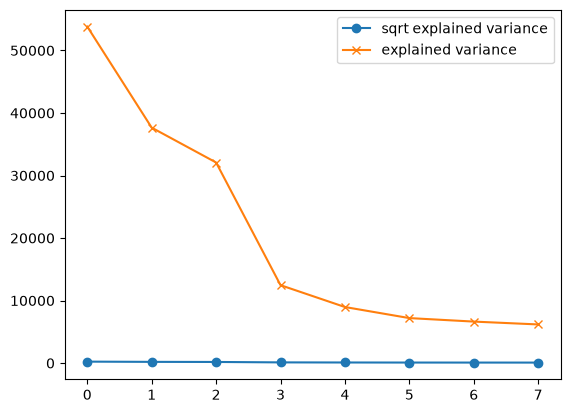

In [62]:
fig, ax = plt.subplots()

sqrt_exp_var = np.sqrt(exp_var)
line1, = ax.plot(sqrt_exp_var, marker='o', label='sqrt explained variance')
line2, = ax.plot(exp_var,      marker='x', label='explained variance')
ax.legend()
plt.show()
plt.close('all')

In [22]:
accumulated_variance[2]

np.float64(0.4479098990559578)

In [46]:
Xplan_pca_transformed_3d.shape

(728, 3)

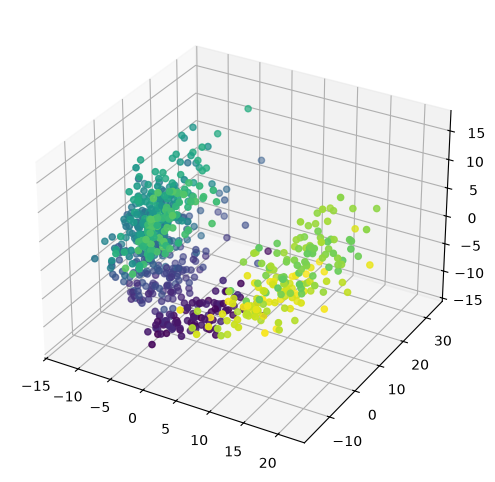

In [44]:
Xplan_pca_transformed_3d = Xplan_pca_transformed[:, :3]
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(projection='3d')

n = len(Xplan_pca_transformed_3d)
colors = plt.cm.viridis(np.linspace(0, 1, n))

ax.scatter(Xplan_pca_transformed_3d[:, 0],
           Xplan_pca_transformed_3d[:, 1],
           Xplan_pca_transformed_3d[:, 2],
           c=colors)
plt.show()

In [63]:
Xc = Xplan - Xplan.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
scatter_eigvals = S**2        # eigenvalues of scatter matrix
components = Vt               # principal directions, shape (d, d)

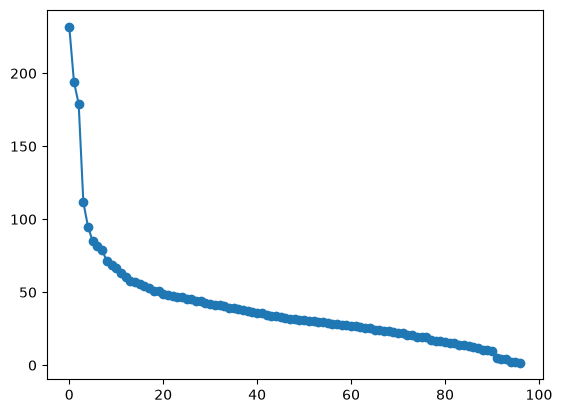

: 

In [ ]:
plt.plot(jnp.sqrt(scatter_eigvals), marker = 'o')